# Drop Token Game: Human vs AI with Minimax Algorithm

This notebook implements a 5×5 Drop Token game where a human player competes against an AI using the Minimax algorithm with depth 3.

## Game Rules:
- **Objective**: Align three tokens in a row (horizontally, vertically, or diagonally)
- **Turns**: Players alternate dropping tokens into columns
- **Tokens fall**: Tokens drop to the lowest available row in the selected column
- **Win**: First to get three in a row wins
- **Draw**: Game ends in draw if board is full with no winner


o	BITS IDs of all team members
o	Their individual contribution percentages

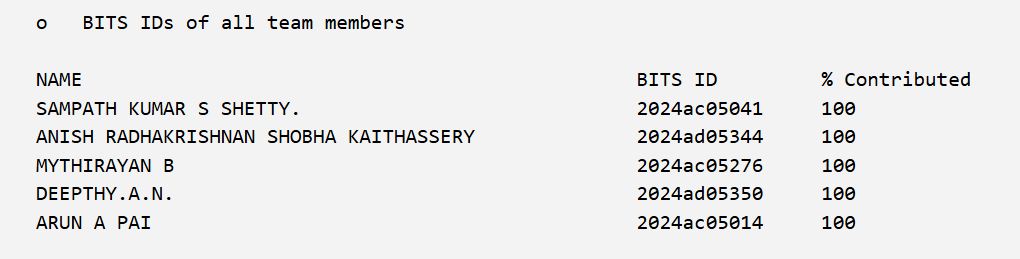



Requirements:
•	Grid Representation: Use a 5-row × 5-column 2D array to represent the board.
•	Human Player: The human selects a column to drop their token, which lands in the lowest available row in that column. Ensure that the column is not already full.
•	Computer Player: The AI player uses the Minimax algorithm with a fixed depth of 3 to decide the best move based on winning, blocking, and strategic positioning.
•	Game Logic: The players take turns dropping tokens into the grid. After each move, the board updates and checks for a win (three in a row horizontally, vertically, or diagonally) or a draw (if all columns are full).
•	Output: Display the board after each move and declare a winner or a draw when the game ends.


In [1]:
import numpy as np

class DropTokenGame:
    def __init__(self):
        # Create a 5x5 board filled with zeros (0=empty, 1=human, -1=SYS)
        self.board = np.zeros((5, 5), dtype=int)
        self.human_player = 1
        self.sys_player = -1
        self.current_player = self.human_player  # Human starts first

    def display_board(self):
        # Print the board with column numbers
        print("\n  0   1   2   3   4")
        print(" ─────────────────")
        for i in range(5):
            row_str = "|"
            for j in range(5):
                if self.board[i][j] == 1:
                    row_str += " H |"  # Human token
                elif self.board[i][j] == -1:
                    row_str += " S |"  # SYS token
                else:
                    row_str += "   |"  # Empty
            print(row_str)
            print(" ─────────────────")
        print()

    def is_valid_move(self, col):
        # Check if a move to the given column is valid (not full and in range)
        return 0 <= col < 5 and self.board[0][col] == 0

    def make_move(self, col, player):
        # Drop a token into the specified column for the player
        for row in range(4, -1, -1):  # Start from bottom row
            if self.board[row][col] == 0:
                self.board[row][col] = player
                return True
        return False  # Column is full

    def undo_move(self, col):
        # Remove the top token from the specified column
        for row in range(5):
            if self.board[row][col] != 0:
                self.board[row][col] = 0
                return True
        return False

    def check_winner(self):
        # Check for 3 in a row (horizontal, vertical, diagonal)
        for row in range(5):
            for col in range(3):
                if self.board[row][col] != 0 and \
                   self.board[row][col] == self.board[row][col+1] == self.board[row][col+2]:
                    return self.board[row][col]
        for row in range(3):
            for col in range(5):
                if self.board[row][col] != 0 and \
                   self.board[row][col] == self.board[row+1][col] == self.board[row+2][col]:
                    return self.board[row][col]
        for row in range(3):
            for col in range(3):
                if self.board[row][col] != 0 and \
                   self.board[row][col] == self.board[row+1][col+1] == self.board[row+2][col+2]:
                    return self.board[row][col]
        for row in range(3):
            for col in range(2, 5):
                if self.board[row][col] != 0 and \
                   self.board[row][col] == self.board[row+1][col-1] == self.board[row+2][col-2]:
                    return self.board[row][col]
        return 0  # No winner

    def is_board_full(self):
        # Check if the board is full (no empty spaces in top row)
        return np.all(self.board[0] != 0)

    def get_valid_moves(self):
        # Return a list of columns where a move is possible
        return [col for col in range(5) if self.is_valid_move(col)]

    def evaluate_position(self, player):
        # Evaluate the board for the given player
        winner = self.check_winner()
        if winner == player:
            return 1000  # Win
        elif winner == -player:
            return -1000  # Loss
        score = 0
        # Directions: horizontal, vertical, diagonal \, diagonal /
        directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
        for row in range(5):
            for col in range(5):
                for dr, dc in directions:
                    if self.is_valid_line_start(row, col, dr, dc):
                        score += self.evaluate_line(row, col, dr, dc, player)
        # Bonus for tokens in center columns
        for row in range(5):
            for col in [1, 2, 3]:
                if self.board[row][col] == player:
                    score += 10
                elif self.board[row][col] == -player:
                    score -= 10
        return score

    def is_valid_line_start(self, row, col, dr, dc):
        # Check if a line of 3 can start from (row, col) in direction (dr, dc)
        end_row = row + 2 * dr
        end_col = col + 2 * dc
        return 0 <= end_row < 5 and 0 <= end_col < 5

    def evaluate_line(self, row, col, dr, dc, player):
        # Evaluate a line of 3 for the player
        positions = [self.board[row + i * dr][col + i * dc] for i in range(3)]
        player_count = positions.count(player)
        opponent_count = positions.count(-player)
        empty_count = positions.count(0)
        if opponent_count > 0:
            return 0  # Blocked by opponent
        if player_count == 2 and empty_count == 1:
            return 50  # Two in a row
        elif player_count == 1 and empty_count == 2:
            return 5  # One in a row
        return 0

    def minimax(self, depth, maximizing_player, alpha=float('-inf'), beta=float('inf')):
        # Minimax algorithm with alpha-beta pruning
        winner = self.check_winner()
        if winner != 0 or depth == 0 or self.is_board_full():
            if maximizing_player:
                return self.evaluate_position(self.sys_player), None
            else:
                return self.evaluate_position(self.human_player), None
        valid_moves = self.get_valid_moves()
        best_col = valid_moves[0] if valid_moves else None
        if maximizing_player:
            max_eval = float('-inf')
            for col in valid_moves:
                self.make_move(col, self.sys_player)
                eval_score, _ = self.minimax(depth - 1, False, alpha, beta)
                self.undo_move(col)
                if eval_score > max_eval:
                    max_eval = eval_score
                    best_col = col
                alpha = max(alpha, eval_score)
                if beta <= alpha:
                    break
            return max_eval, best_col
        else:
            min_eval = float('inf')
            for col in valid_moves:
                self.make_move(col, self.human_player)
                eval_score, _ = self.minimax(depth - 1, True, alpha, beta)
                self.undo_move(col)
                if eval_score < min_eval:
                    min_eval = eval_score
                    best_col = col
                beta = min(beta, eval_score)
                if beta <= alpha:
                    break
            return min_eval, best_col

    def get_sys_move(self):
        # Get the best move for SYS using minimax
        _, best_col = self.minimax(depth=3, maximizing_player=True)
        return best_col

    def get_human_move(self):
        # Ask the human player for a valid move
        while True:
            try:
                col = int(input("Enter column (0-4) for your move: "))
                if self.is_valid_move(col):
                    return col
                else:
                    print("Invalid move! Column is full or out of range. Try again.")
            except ValueError:
                print("Please enter a valid number between 0 and 4.")

    def play_game(self):
        # Main game loop
        print("=== Drop Token Game: Human vs SYS ===")
        print("You are 'H' and SYS is 'S'")
        print("Goal: Get 3 in a row (horizontal, vertical, or diagonal)")
        print("Choose column 0-4 to drop your token\n")
        self.display_board()
        while True:
            winner = self.check_winner()
            if winner != 0:
                if winner == self.human_player:
                    print("🎉 Congratulations! You won!")
                else:
                    print("🤖 SYS wins! Better luck next time.")
                break
            if self.is_board_full():
                print("🤝 It's a draw! Board is full.")
                break
            if self.current_player == self.human_player:
                print("Your turn:")
                col = self.get_human_move()
                self.make_move(col, self.human_player)
                print(f"You dropped a token in column {col}")
                self.current_player = self.sys_player
            else:
                print("SYS is thinking...")
                col = self.get_sys_move()
                self.make_move(col, self.sys_player)
                print(f"SYS dropped a token in column {col}")
                self.current_player = self.human_player
            self.display_board()

def start_new_game():
    # Start a new Drop Token game
    game = DropTokenGame()
    game.play_game()
    return game

Rules to Play Drop Token:
1.	Objective: The goal is to align three of your tokens in a row (horizontally, vertically, or diagonally) on a 5×5 grid.
2.	Turns: The players take turns dropping a token into a column. The token falls to the lowest available row in that column.
3.	Winning Condition: A player wins if they align three tokens in a row.
4.	Draw Condition: The game ends in a draw if all columns are full and no player has won.

**Symbols:**
- `H` = Human player (you)
- `A` = AI player
- Empty spaces = available positions

## Static Evaluation Function Design & Justification

### How the Computer Decides Which Move is Best

The computer uses a scoring system to judge how good each board position is. It looks at 4 main things:

### 1. **Winning or Losing Right Away** (1000 points)
- **If the computer can win immediately**: Gets +1000 points (best possible!)
- **If the human can win next turn**: Gets -1000 points (worst possible!)
- **Why this matters**: The computer should never miss a chance to win or let the human win

### 2. **Almost Winning (Two in a Row)** (50 points)
- **If you have 2 tokens in a line**: Gets +50 points (very good!)
- **If opponent has 2 tokens in a line**: Gets -50 points (dangerous!)
- **Why this matters**: Having 2 in a row means you can win on the next turn

### 3. **Building for the Future (One in a Row)** (5 points)
- **If you have 1 token with room to grow**: Gets +5 points (small advantage)
- **Why this matters**: You need to start somewhere to build winning lines

### 4. **Controlling the Center** (10 points per token)
- **Tokens in middle columns (1, 2, 3)**: Gets +10 points each
- **Why this matters**: Center tokens can connect in more directions (up, down, diagonal)

### Example: How the Computer Thinks

```
Look at this game board:
  0   1   2   3   4
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   | H |   |   |  ← Human has 1 token in center
 ─────────────────
|   | S | H |   |   |  ← Human has 2 tokens in a column!
 ─────────────────
|   |   | S |   |   |  ← Computer is trying to block
 ─────────────────
|   |   |   |   |   |
 ─────────────────
```

### What the Computer Sees:

**For the Human Player:**
- No immediate win = 0 points
- Has 2 tokens in a row vertically = +50 points (dangerous for computer!)
- Has 2 tokens in center column = +20 points (good position)
- **Total Human Score**: +70 points

**For the Computer (SYS):**
- No immediate win = 0 points
- No threatening lines = 0 points
- Has 1 token in center column = +10 points
- Has 1 token near center = +10 points
- **Total Computer Score**: +20 points

### **Final Result**: Human is ahead by 50 points

This tells the computer that:
- The human player is in a much better position
- The human has a dangerous threat (2 in a row)
- The computer needs to block or create its own threat

### Why This System Works Well:

1. **Most Important First**: Winning/losing comes before everything else
2. **Thinks Ahead**: Looks for threats before they become wins
3. **Plays Smart**: Values center control for better options
4. **Easy to Understand**: Each part has a clear reason

## Understanding the Point System

### What Do the Points Mean?

The points are like grades that tell the computer how good or bad a position is:

- **Positive points** = Good for the computer
- **Negative points** = Bad for the computer  
- **Higher numbers** = More important

Think of it like a report card where A+ = 1000 points and F = -1000 points.

### How Were These Point Values Chosen?

The point values follow a simple rule: **More urgent situations get higher points**

#### 1. **Why 1000 points for winning/losing?**
- **Logic**: Nothing is more important than winning or avoiding defeat
- **Comparison**: This is 20 times bigger than the next highest score (50 points)
- **Result**: The computer will ALWAYS choose to win or block a loss, no matter what else is happening

#### 2. **Why 50 points for two-in-a-row?**
- **Logic**: This creates an immediate threat to win next turn
- **Comparison**: This is 10 times bigger than foundation building (5 points)
- **Comparison**: This is 5 times bigger than center control (10 points)
- **Result**: The computer prioritizes creating threats over slow positional play

#### 3. **Why 10 points for center control?**
- **Logic**: Center positions offer more connection possibilities
- **Comparison**: This is 2 times bigger than basic foundation building (5 points)
- **Result**: The computer slightly prefers center moves when other factors are equal

#### 4. **Why 5 points for one-in-a-row?**
- **Logic**: You need to start building somewhere, but it's not urgent
- **Comparison**: This is the smallest bonus - just a tiebreaker
- **Result**: The computer considers long-term building but doesn't prioritize it

### The Mathematics Behind It

The point gaps create a clear priority order:

```
1000 (Win/Loss)     ←  20x more important than threats
  ↓
 50 (Threats)       ←  5x more important than center control
  ↓  
 10 (Center)        ←  2x more important than foundation
  ↓
  5 (Foundation)    ←  Basic building points
```

### Why These Specific Numbers Work

1. **Large Gaps Prevent Confusion**: The computer can't accidentally choose 10 small advantages over 1 big threat
2. **Clear Priorities**: Even if the computer has 15 foundation pieces (5×15=75), it will still prioritize one threat (50) plus some center control (10+)
3. **Realistic Game Logic**: Matches how humans think - immediate threats matter more than long-term plans

### Real Example: Point Calculation

```
If the computer sees this position:
- Human has 2-in-a-row: -50 points (bad for computer!)
- Computer has 3 center tokens: +30 points (3×10)
- Computer has 2 foundation pieces: +10 points (2×5)

Total: -50 + 30 + 10 = -10 points (still bad overall)
```

This tells the computer: "Even though I have good positioning (+40), the human's threat (-50) makes this a losing position. I must block it!"

In [2]:
# Start a new game!
game = start_new_game()

=== Drop Token Game: Human vs SYS ===
You are 'H' and SYS is 'S'
Goal: Get 3 in a row (horizontal, vertical, or diagonal)
Choose column 0-4 to drop your token


  0   1   2   3   4
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────

Your turn:
You dropped a token in column 1

  0   1   2   3   4
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   | H |   |   |   |
 ─────────────────

SYS is thinking...
SYS dropped a token in column 0

  0   1   2   3   4
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────
|   |   |   |   |   |
 ─────────────────
| S | H |   |   |   |
 ─────────────────

Your tur